# BioHub Cell Tracking During Development
## Chapter 46 — Multi-Sample Division Pipeline Audit (V4)

**Purpose:** Re-run the Chapter 46 diagnostic against the new Chapter 46A V12 multi-sample artifacts.

V12 successfully reproduced the historical **Chapter 34 → 35 → 36 → 37** pipeline on three samples containing **13 binary GT divisions**. This notebook asks the original Chapter 46 question with enough events to test whether the one-event diagnosis generalizes:

> **Across these 13 ground-truth divisions, where do true divisions fail in the current pipeline?**

### Diagnostic contract

This notebook does **not** improve the model. It does not tune thresholds, rescue daughters, split tracks with ground truth, or train a division classifier.

It measures:

- whether parent/daughter candidates exist in Chapter 34;
- whether they survive Chapter 36 filtering;
- whether their best matches are temporally displaced by ±1 frame;
- which Chapter 37 tracks receive the matched parent/daughters;
- whether daughter tracks predate the division;
- whether daughters share a track;
- whether daughter tracks remain distinct from the parent;
- whether the resulting topology is compatible with a true division.

The output is intended to decide what **Chapter 47** should fix.


> **V3 GT-discovery fix:** V2 discovered 398 candidate paths but misidentified the sample IDs because it assumed a fixed Kaggle directory depth. V3 extracts the actual BioHub sample-ID component from each path and validates the GEFF node/edge schema before accepting the store.

> **V4 GT-discovery fix:** Uses the exact `.geff` discovery and `sample_id_from_geff()` logic that already succeeded in Chapter 46A V12. This removes the generic recursive Zarr path inference used in V2/V3.

In [5]:
!pip install -q zarr

In [6]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, Optional
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 1. Configuration

The physical scaling and match radii preserve the conventions used by the original Chapter 46 audit.

The notebook searches all attached Kaggle inputs recursively for the **V12 combined CSV artifacts**, so the V12 notebook output can be attached as a Kaggle input without hard-coding a dataset slug.


In [7]:
@dataclass(frozen=True)
class Config:
    competition_dir: Path = Path(
        "/kaggle/input/competitions/biohub-cell-tracking-during-development"
    )
    input_root: Path = Path("/kaggle/input")
    output_dir: Path = Path("/kaggle/working/chapter46_multisample_audit")

    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625

    strong_match_radius_physical: float = 8.0
    match_radius_physical: float = 15.0
    temporal_offsets: Tuple[int, ...] = (-1, 0, 1)

CONFIG = Config()
CONFIG.output_dir.mkdir(parents=True, exist_ok=True)
CONFIG


Config(competition_dir=PosixPath('/kaggle/input/competitions/biohub-cell-tracking-during-development'), input_root=PosixPath('/kaggle/input'), output_dir=PosixPath('/kaggle/working/chapter46_multisample_audit'), z_scale=1.625, y_scale=0.40625, x_scale=0.40625, strong_match_radius_physical=8.0, match_radius_physical=15.0, temporal_offsets=(-1, 0, 1))

## 2. Discover the V12 artifacts

Required combined tables:

- `chapter34_top200_detections_multisample.csv`
- `chapter36_filtered_detections_multisample.csv`
- `chapter37_refined_track_nodes_multisample.csv`

The audit intentionally uses the same stage boundaries as the original Chapter 46 diagnosis.


In [8]:
REQUIRED_FILES = {
    "ch34": "chapter34_top200_detections_multisample.csv",
    "ch36": "chapter36_filtered_detections_multisample.csv",
    "ch37": "chapter37_refined_track_nodes_multisample.csv",
}

def find_unique_file(filename: str) -> Path:
    matches = list(CONFIG.input_root.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} under /kaggle/input. "
            "Attach the executed Chapter 46A V12 notebook output as an input."
        )
    if len(matches) > 1:
        print(f"WARNING: multiple matches for {filename}; using {matches[0]}")
        for p in matches:
            print("  ", p)
    return matches[0]

stage_paths = {stage: find_unique_file(name) for stage, name in REQUIRED_FILES.items()}

print("Discovered V12 stage files:")
for stage, path in stage_paths.items():
    print(f"  {stage}: {path}")


Discovered V12 stage files:
  ch34: /kaggle/input/datasets/emailchrismathews/46datav12/chapter34_top200_detections_multisample.csv
  ch36: /kaggle/input/datasets/emailchrismathews/46datav12/chapter36_filtered_detections_multisample.csv
  ch37: /kaggle/input/datasets/emailchrismathews/46datav12/chapter37_refined_track_nodes_multisample.csv


In [9]:
stage_tables = {
    stage: pd.read_csv(path)
    for stage, path in stage_paths.items()
}

for stage, df in stage_tables.items():
    if "sample_id" not in df.columns:
        raise ValueError(
            f"{stage} artifact has no sample_id column. "
            "This notebook requires the V12 multi-sample outputs."
        )
    df["sample_id"] = df["sample_id"].astype(str)
    print(
        f"{stage}: {len(df):,} rows | "
        f"{df['sample_id'].nunique()} samples | "
        f"{sorted(df['sample_id'].unique())}"
    )

shared_samples = sorted(
    set(stage_tables["ch34"]["sample_id"])
    & set(stage_tables["ch36"]["sample_id"])
    & set(stage_tables["ch37"]["sample_id"])
)

print("\nShared auditable samples:", shared_samples)
if len(shared_samples) != 3:
    warnings.warn(
        f"Expected 3 V12 samples, found {len(shared_samples)} shared samples. "
        "The audit will continue on the intersection."
    )


ch34: 60,000 rows | 3 samples | ['6bba_09961292', '6bba_48816121', '6bba_afb141ff']
ch36: 15,000 rows | 3 samples | ['6bba_09961292', '6bba_48816121', '6bba_afb141ff']
ch37: 13,892 rows | 3 samples | ['6bba_09961292', '6bba_48816121', '6bba_afb141ff']

Shared auditable samples: ['6bba_09961292', '6bba_48816121', '6bba_afb141ff']


## 3. Load competition ground truth

A binary GT division is defined exactly as in the original audit: a GT parent node with **out-degree exactly 2**.

Events with out-degree >2 are counted separately and are not silently converted into binary divisions.


In [10]:
def find_train_dir() -> Path:
    for candidate in (
        CONFIG.competition_dir / "train",
        CONFIG.competition_dir / "training",
    ):
        if candidate.exists():
            return candidate

    geff = list(CONFIG.competition_dir.rglob("*.geff"))
    if geff:
        return geff[0].parent

    raise FileNotFoundError(
        f"Could not locate training GEFF data below {CONFIG.competition_dir}"
    )


TRAIN_DIR = find_train_dir()
print("Training directory:", TRAIN_DIR)


def sample_id_from_geff(path: Path) -> str:
    # This is the exact naming rule that V12 used successfully.
    return path.name[:-5] if path.name.endswith(".geff") else path.stem


def load_geff_tables(geff_path: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Proven GEFF loader from the successful Chapter 46A V12 run.
    """
    geff = zarr.open(geff_path, mode="r")

    nodes = pd.DataFrame({
        "gt_node_id": np.asarray(geff["nodes/ids"][:]),
        "t": np.asarray(geff["nodes/props/t/values"][:]).astype(int),
        "z": np.asarray(geff["nodes/props/z/values"][:]).astype(float),
        "y": np.asarray(geff["nodes/props/y/values"][:]).astype(float),
        "x": np.asarray(geff["nodes/props/x/values"][:]).astype(float),
    })

    edge_ids = np.asarray(geff["edges/ids"][:])

    edges = pd.DataFrame({
        "gt_source": edge_ids[:, 0],
        "gt_target": edge_ids[:, 1],
    })

    return nodes, edges


# IMPORTANT:
# Use the same discovery strategy that V12 already proved against this exact
# Kaggle competition layout. Do not infer sample IDs from arbitrary path depth.
geff_paths = sorted(TRAIN_DIR.glob("*.geff"))

if not geff_paths:
    geff_paths = sorted(TRAIN_DIR.rglob("*.geff"))

if not geff_paths:
    raise FileNotFoundError(
        f"No .geff samples found under {TRAIN_DIR}"
    )


GEFF_PATHS: Dict[str, Path] = {}

for geff_path in geff_paths:
    sample_id = sample_id_from_geff(geff_path)

    # Keep the first exact filename match for each sample.
    GEFF_PATHS.setdefault(sample_id, geff_path)


print("Competition GT samples discovered:", len(GEFF_PATHS))
print("First GT sample IDs:", sorted(GEFF_PATHS)[:10])

missing_gt = [s for s in shared_samples if s not in GEFF_PATHS]

if missing_gt:
    print("\nRequested V12 sample IDs:", shared_samples)

    # Show exact candidate filenames to make any remaining mismatch obvious.
    print("\nFirst 20 GEFF filenames:")
    for p in geff_paths[:20]:
        print(" ", p.name)

    raise FileNotFoundError(
        "Could not resolve GT GEFF path for V12 sample(s): "
        + ", ".join(missing_gt)
    )


print("\nAll V12 sample IDs resolved to GT GEFF stores:")
for sample_id in shared_samples:
    print(f"  {sample_id}: {GEFF_PATHS[sample_id]}")


Training directory: /kaggle/input/competitions/biohub-cell-tracking-during-development/train
Competition GT samples discovered: 199
First GT sample IDs: ['44b6_0113de3b', '44b6_0b24845f', '44b6_0c582fdc', '44b6_0db75fae', '44b6_12dfb391', '44b6_144b256d', '44b6_1574802b', '44b6_18ced818', '44b6_1d530831', '44b6_24264f12']

All V12 sample IDs resolved to GT GEFF stores:
  6bba_09961292: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_09961292.geff
  6bba_48816121: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_48816121.geff
  6bba_afb141ff: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/6bba_afb141ff.geff


In [11]:
division_rows = []
outdegree_gt2_rows = []

for sample_id in shared_samples:
    nodes, edges = load_geff_tables(GEFF_PATHS[sample_id])
    node_lookup = nodes.set_index("gt_node_id")

    outgoing = edges.groupby("gt_source")["gt_target"].apply(list)

    for parent_id, daughter_ids in outgoing.items():
        if len(daughter_ids) > 2:
            outdegree_gt2_rows.append({
                "sample_id": sample_id,
                "parent_id": parent_id,
                "outdegree": len(daughter_ids),
            })
            continue

        if len(daughter_ids) != 2:
            continue

        if parent_id not in node_lookup.index:
            continue
        if not all(d in node_lookup.index for d in daughter_ids):
            continue

        parent = node_lookup.loc[parent_id]
        da = node_lookup.loc[daughter_ids[0]]
        db = node_lookup.loc[daughter_ids[1]]

        division_rows.append({
            "sample_id": sample_id,
            "division_id": f"{sample_id}:{int(parent_id)}",
            "parent_id": parent_id,
            "parent_t": int(parent["t"]),
            "parent_z": float(parent["z"]),
            "parent_y": float(parent["y"]),
            "parent_x": float(parent["x"]),
            "daughter_a_id": daughter_ids[0],
            "daughter_a_t": int(da["t"]),
            "daughter_a_z": float(da["z"]),
            "daughter_a_y": float(da["y"]),
            "daughter_a_x": float(da["x"]),
            "daughter_b_id": daughter_ids[1],
            "daughter_b_t": int(db["t"]),
            "daughter_b_z": float(db["z"]),
            "daughter_b_y": float(db["y"]),
            "daughter_b_x": float(db["x"]),
        })

gt_divisions = pd.DataFrame(division_rows)
gt_outdegree_gt2 = pd.DataFrame(outdegree_gt2_rows)

print("Binary GT divisions:", len(gt_divisions))
print("GT outdegree >2 events:", len(gt_outdegree_gt2))
display(
    gt_divisions.groupby("sample_id")
    .size()
    .rename("gt_binary_divisions")
    .reset_index()
)


Binary GT divisions: 13
GT outdegree >2 events: 0


,sample_id,gt_binary_divisions
0,6bba_09961292,4
1,6bba_48816121,5
2,6bba_afb141ff,4


## 4. Add physical coordinates and matching helpers

For each GT parent/daughter, the audit measures the nearest pipeline candidate:

- at the **exact GT frame**;
- within a **±1 frame window**.

A candidate within **15 physical units** counts as adequate. The 8-unit strong-match distance is preserved as an additional diagnostic.


In [12]:
def add_physical_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["z_physical"] = out["z"].astype(float) * CONFIG.z_scale
    out["y_physical"] = out["y"].astype(float) * CONFIG.y_scale
    out["x_physical"] = out["x"].astype(float) * CONFIG.x_scale
    return out

for stage in stage_tables:
    stage_tables[stage] = add_physical_coordinates(stage_tables[stage])


def physical_distance_to_rows(df: pd.DataFrame, z: float, y: float, x: float) -> np.ndarray:
    gz = float(z) * CONFIG.z_scale
    gy = float(y) * CONFIG.y_scale
    gx = float(x) * CONFIG.x_scale

    dz = df["z_physical"].to_numpy(float) - gz
    dy = df["y_physical"].to_numpy(float) - gy
    dx = df["x_physical"].to_numpy(float) - gx
    return np.sqrt(dz * dz + dy * dy + dx * dx)


def nearest_candidate_at_t(
    df: pd.DataFrame,
    sample_id: str,
    t: int,
    z: float,
    y: float,
    x: float,
) -> Optional[dict]:
    subset = df[
        (df["sample_id"].astype(str) == str(sample_id))
        & (df["t"].astype(int) == int(t))
    ]

    if subset.empty:
        return None

    dists = physical_distance_to_rows(subset, z, y, x)
    pos = int(np.argmin(dists))
    row = subset.iloc[pos]

    return {
        "distance": float(dists[pos]),
        "matched_t": int(row["t"]),
        "index": row.name,
        "row": row,
    }


def nearest_candidate_window(
    df: pd.DataFrame,
    sample_id: str,
    expected_t: int,
    z: float,
    y: float,
    x: float,
) -> Optional[dict]:
    candidates = []
    for offset in CONFIG.temporal_offsets:
        result = nearest_candidate_at_t(
            df, sample_id, int(expected_t) + int(offset), z, y, x
        )
        if result is not None:
            result = dict(result)
            result["frame_offset"] = int(result["matched_t"] - int(expected_t))
            candidates.append(result)

    if not candidates:
        return None

    return min(candidates, key=lambda r: r["distance"])


def adequate(match: Optional[dict]) -> bool:
    return match is not None and match["distance"] <= CONFIG.match_radius_physical


def strong(match: Optional[dict]) -> bool:
    return match is not None and match["distance"] <= CONFIG.strong_match_radius_physical


## 5. Audit each GT division through Ch34 → Ch36 → Ch37

The primary failure label is assigned to the **earliest measured failure** in the pipeline.

This keeps the diagnosis causal: if a valid daughter exists in Ch34 but disappears in Ch36, later track topology problems are still measured, but the primary failure remains filtering.


In [13]:
def track_info_from_match(match: Optional[dict]) -> dict:
    if match is None:
        return {
            "track_id": np.nan,
            "track_start_t": np.nan,
            "track_end_t": np.nan,
        }

    row = match["row"]
    track_id = row.get("track_id", np.nan)

    return {
        "track_id": track_id,
        "track_start_t": row.get("start_t", np.nan),
        "track_end_t": row.get("end_t", np.nan),
    }


def assign_primary_failure(row: dict) -> str:
    # Earliest measured failure wins.
    if not row["parent_ch34_adequate_window"]:
        return "NO_PARENT_CANDIDATE"
    if not row["daughter_a_ch34_adequate_window"]:
        return "NO_DAUGHTER_A_CANDIDATE"
    if not row["daughter_b_ch34_adequate_window"]:
        return "NO_DAUGHTER_B_CANDIDATE"

    if not row["parent_ch36_adequate_window"]:
        return "PARENT_FILTERED"

    da_survives = row["daughter_a_ch36_adequate_window"]
    db_survives = row["daughter_b_ch36_adequate_window"]

    if not da_survives and not db_survives:
        return "BOTH_DAUGHTERS_FILTERED"
    if not da_survives or not db_survives:
        return "DAUGHTER_FILTERED"

    if not row["parent_ch37_adequate_window"]:
        return "PARENT_TRACK_MISSING"
    if not row["daughter_a_ch37_adequate_window"]:
        return "DAUGHTER_A_TRACK_MISSING"
    if not row["daughter_b_ch37_adequate_window"]:
        return "DAUGHTER_B_TRACK_MISSING"

    if row["daughters_share_track"]:
        return "DAUGHTERS_SHARE_TRACK"

    if not row["daughter_tracks_distinct_from_parent"]:
        return "DAUGHTER_ATTACHED_TO_PARENT_TRACK"

    if row["daughter_a_track_predates_division"] or row["daughter_b_track_predates_division"]:
        return "DAUGHTER_TRACK_PREDATES_DIVISION"

    if not row["track_topology_compatible"]:
        return "TRACK_TOPOLOGY_INCOMPATIBLE"

    return "TOPOLOGY_COMPATIBLE"


audit_rows = []

for _, div in gt_divisions.iterrows():
    sample_id = str(div["sample_id"])
    row = dict(div)

    entities = {
        "parent": (
            int(div["parent_t"]),
            float(div["parent_z"]),
            float(div["parent_y"]),
            float(div["parent_x"]),
        ),
        "daughter_a": (
            int(div["daughter_a_t"]),
            float(div["daughter_a_z"]),
            float(div["daughter_a_y"]),
            float(div["daughter_a_x"]),
        ),
        "daughter_b": (
            int(div["daughter_b_t"]),
            float(div["daughter_b_z"]),
            float(div["daughter_b_y"]),
            float(div["daughter_b_x"]),
        ),
    }

    stage_matches = {}

    for stage in ("ch34", "ch36", "ch37"):
        stage_matches[stage] = {}

        for entity, (t, z, y, x) in entities.items():
            exact = nearest_candidate_at_t(
                stage_tables[stage], sample_id, t, z, y, x
            )
            window = nearest_candidate_window(
                stage_tables[stage], sample_id, t, z, y, x
            )

            stage_matches[stage][entity] = window

            row[f"{entity}_{stage}_distance_exact"] = (
                np.nan if exact is None else exact["distance"]
            )
            row[f"{entity}_{stage}_distance_window"] = (
                np.nan if window is None else window["distance"]
            )
            row[f"{entity}_{stage}_matched_t"] = (
                np.nan if window is None else window["matched_t"]
            )
            row[f"{entity}_{stage}_frame_offset"] = (
                np.nan if window is None else window["frame_offset"]
            )
            row[f"{entity}_{stage}_adequate_exact"] = adequate(exact)
            row[f"{entity}_{stage}_adequate_window"] = adequate(window)
            row[f"{entity}_{stage}_strong_window"] = strong(window)

    # Temporal displacement diagnostics from best Ch37 match.
    row["daughter_a_temporally_displaced"] = (
        False
        if stage_matches["ch37"]["daughter_a"] is None
        else stage_matches["ch37"]["daughter_a"]["frame_offset"] != 0
    )
    row["daughter_b_temporally_displaced"] = (
        False
        if stage_matches["ch37"]["daughter_b"] is None
        else stage_matches["ch37"]["daughter_b"]["frame_offset"] != 0
    )

    # Track identity/topology.
    p_info = track_info_from_match(stage_matches["ch37"]["parent"])
    da_info = track_info_from_match(stage_matches["ch37"]["daughter_a"])
    db_info = track_info_from_match(stage_matches["ch37"]["daughter_b"])

    row["parent_track_id"] = p_info["track_id"]
    row["parent_track_start_t"] = p_info["track_start_t"]
    row["parent_track_end_t"] = p_info["track_end_t"]

    row["daughter_a_track_id"] = da_info["track_id"]
    row["daughter_a_track_start_t"] = da_info["track_start_t"]
    row["daughter_a_track_end_t"] = da_info["track_end_t"]

    row["daughter_b_track_id"] = db_info["track_id"]
    row["daughter_b_track_start_t"] = db_info["track_start_t"]
    row["daughter_b_track_end_t"] = db_info["track_end_t"]

    p_tid = row["parent_track_id"]
    da_tid = row["daughter_a_track_id"]
    db_tid = row["daughter_b_track_id"]

    ids_known = not (
        pd.isna(p_tid) or pd.isna(da_tid) or pd.isna(db_tid)
    )

    row["daughters_share_track"] = (
        bool(ids_known and da_tid == db_tid)
    )
    row["daughter_tracks_distinct_from_parent"] = (
        bool(ids_known and da_tid != p_tid and db_tid != p_tid)
    )

    parent_t = int(div["parent_t"])

    row["daughter_a_track_predates_division"] = (
        False
        if pd.isna(row["daughter_a_track_start_t"])
        else int(row["daughter_a_track_start_t"]) <= parent_t
    )
    row["daughter_b_track_predates_division"] = (
        False
        if pd.isna(row["daughter_b_track_start_t"])
        else int(row["daughter_b_track_start_t"]) <= parent_t
    )

    row["track_topology_compatible"] = bool(
        ids_known
        and not row["daughters_share_track"]
        and row["daughter_tracks_distinct_from_parent"]
        and not row["daughter_a_track_predates_division"]
        and not row["daughter_b_track_predates_division"]
    )

    row["primary_failure_stage"] = assign_primary_failure(row)
    audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)

print("Audited GT divisions:", len(audit_df))
display(audit_df.head())


Audited GT divisions: 13


,sample_id,division_id,parent_id,parent_t,parent_z,parent_y,parent_x,daughter_a_id,daughter_a_t,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_id,daughter_b_t,daughter_b_z,daughter_b_y,daughter_b_x,parent_ch34_distance_exact,parent_ch34_distance_window,parent_ch34_matched_t,parent_ch34_frame_offset,parent_ch34_adequate_exact,parent_ch34_adequate_window,parent_ch34_strong_window,daughter_a_ch34_distance_exact,daughter_a_ch34_distance_window,daughter_a_ch34_matched_t,daughter_a_ch34_frame_offset,daughter_a_ch34_adequate_exact,daughter_a_ch34_adequate_window,daughter_a_ch34_strong_window,daughter_b_ch34_distance_exact,daughter_b_ch34_distance_window,daughter_b_ch34_matched_t,daughter_b_ch34_frame_offset,daughter_b_ch34_adequate_exact,daughter_b_ch34_adequate_window,daughter_b_ch34_strong_window,parent_ch36_distance_exact,parent_ch36_distance_window,parent_ch36_matched_t,parent_ch36_frame_offset,parent_ch36_adequate_exact,parent_ch36_adequate_window,parent_ch36_strong_window,daughter_a_ch36_distance_exact,daughter_a_ch36_distance_window,daughter_a_ch36_matched_t,daughter_a_ch36_frame_offset,daughter_a_ch36_adequate_exact,daughter_a_ch36_adequate_window,daughter_a_ch36_strong_window,daughter_b_ch36_distance_exact,daughter_b_ch36_distance_window,daughter_b_ch36_matched_t,daughter_b_ch36_frame_offset,daughter_b_ch36_adequate_exact,daughter_b_ch36_adequate_window,daughter_b_ch36_strong_window,parent_ch37_distance_exact,parent_ch37_distance_window,parent_ch37_matched_t,parent_ch37_frame_offset,parent_ch37_adequate_exact,parent_ch37_adequate_window,parent_ch37_strong_window,daughter_a_ch37_distance_exact,daughter_a_ch37_distance_window,daughter_a_ch37_matched_t,daughter_a_ch37_frame_offset,daughter_a_ch37_adequate_exact,daughter_a_ch37_adequate_window,daughter_a_ch37_strong_window,daughter_b_ch37_distance_exact,daughter_b_ch37_distance_window,daughter_b_ch37_matched_t,daughter_b_ch37_frame_offset,daughter_b_ch37_adequate_exact,daughter_b_ch37_adequate_window,daughter_b_ch37_strong_window,daughter_a_temporally_displaced,daughter_b_temporally_displaced,parent_track_id,parent_track_start_t,parent_track_end_t,daughter_a_track_id,daughter_a_track_start_t,daughter_a_track_end_t,daughter_b_track_id,daughter_b_track_start_t,daughter_b_track_end_t,daughters_share_track,daughter_tracks_distinct_from_parent,daughter_a_track_predates_division,daughter_b_track_predates_division,track_topology_compatible,primary_failure_stage
0,6bba_09961292,6bba_09961292:25000920,25000920,24,3.0,82.0,125.0,26000956,25,4.0,83.0,111.0,26000987,25,1.0,90.0,136.0,9.475297,3.275292,23,-1,True,True,True,5.450416,5.296852,26,1,True,True,True,13.082259,7.198768,24,-1,True,True,True,9.475297,9.475297,24,0,True,True,False,20.466293,6.254139,24,-1,False,True,True,26.453083,15.885362,24,-1,False,False,False,9.475297,9.475297,24,0,True,True,False,21.596305,6.254139,24,-1,False,True,True,26.453083,15.885362,24,-1,False,False,False,True,True,185,NaN,NaN,185,NaN,NaN,185,NaN,NaN,True,False,False,False,False,DAUGHTER_FILTERED
1,6bba_09961292,6bba_09961292:45001493,45001493,44,4.0,224.0,135.0,46001530,45,6.0,221.0,142.0,46001531,45,4.0,224.0,131.0,2.333729,2.333729,44,0,True,True,True,9.492699,2.031250,44,-1,True,True,True,9.056733,1.464755,44,-1,True,True,True,11.272980,10.468330,45,1,True,True,False,9.492699,9.492699,45,0,True,True,False,10.212967,9.967623,44,-1,True,True,False,11.272980,10.468330,45,1,True,True,False,9.492699,9.492699,45,0,True,True,False,10.212967,9.967623,44,-1,True,True,False,False,True,199,NaN,NaN,199,NaN,NaN,17,NaN,NaN,False,False,False,False,False,DAUGHTER_ATTACHED_TO_PARENT_TRACK
2,6bba_09961292,6bba_09961292:49001609,49001609,48,8.0,251.0,128.0,50001629,49,8.0,248.0,132.0,50001630,49,7.0,252.0,121.0,10.349413,4.375446,49,1,True,True,True,4.958913,4.958913,49,0,True,True,True,1.284675,1.284675,49,0,True,True,True,10.349413,5.296852,49,1,True,True,True,4.958913,4.958913,49,0,True,True,True,5.915089,5.915089,49,0,True,True,True,10.349413,5.296852,49,1,True,

## 6. Core results

The tables below answer the main Chapter 46 questions:

1. How often do adequate parent/daughter candidates exist at Ch34?
2. How often do daughters disappear by Ch36?
3. How often are daughters temporally displaced?
4. How often does Ch37 produce topology compatible with a true division?
5. Which failure category dominates across the 13 GT events?


In [14]:
summary_rows = []

for entity in ("parent", "daughter_a", "daughter_b"):
    summary_rows.append({
        "entity": entity,
        "ch34_adequate_window_pct": 100 * audit_df[f"{entity}_ch34_adequate_window"].mean(),
        "ch36_adequate_window_pct": 100 * audit_df[f"{entity}_ch36_adequate_window"].mean(),
        "ch37_adequate_window_pct": 100 * audit_df[f"{entity}_ch37_adequate_window"].mean(),
    })

candidate_survival = pd.DataFrame(summary_rows)
display(candidate_survival)


,entity,ch34_adequate_window_pct,ch36_adequate_window_pct,ch37_adequate_window_pct
0,parent,100.0,100.000000,92.307692
1,daughter_a,100.0,92.307692,84.615385
2,daughter_b,100.0,76.923077,76.923077


In [15]:
failure_distribution = (
    audit_df["primary_failure_stage"]
    .value_counts(dropna=False)
    .rename_axis("failure_stage")
    .reset_index(name="count")
)
failure_distribution["percent"] = (
    100 * failure_distribution["count"] / len(audit_df)
)

print("Primary failure distribution:")
display(failure_distribution)

print("\nPer-sample failure distribution:")
per_sample_failures = pd.crosstab(
    audit_df["sample_id"],
    audit_df["primary_failure_stage"],
)
display(per_sample_failures)


Primary failure distribution:


,failure_stage,count,percent
0,DAUGHTERS_SHARE_TRACK,5,38.461538
1,DAUGHTER_ATTACHED_TO_PARENT_TRACK,3,23.076923
2,DAUGHTER_FILTERED,2,15.384615
3,TOPOLOGY_COMPATIBLE,2,15.384615
4,BOTH_DAUGHTERS_FILTERED,1,7.692308



Per-sample failure distribution:


primary_failure_stage,BOTH_DAUGHTERS_FILTERED,DAUGHTERS_SHARE_TRACK,DAUGHTER_ATTACHED_TO_PARENT_TRACK,DAUGHTER_FILTERED,TOPOLOGY_COMPATIBLE
sample_id,,,,,
6bba_09961292,0,1,1,2,0
6bba_48816121,1,1,1,0,2
6bba_afb141ff,0,3,1,0,0


In [16]:
topology_summary = pd.DataFrame([{
    "gt_divisions": len(audit_df),
    "daughter_a_temporally_displaced": int(audit_df["daughter_a_temporally_displaced"].sum()),
    "daughter_b_temporally_displaced": int(audit_df["daughter_b_temporally_displaced"].sum()),
    "either_daughter_temporally_displaced": int(
        (
            audit_df["daughter_a_temporally_displaced"]
            | audit_df["daughter_b_temporally_displaced"]
        ).sum()
    ),
    "daughters_share_track": int(audit_df["daughters_share_track"].sum()),
    "daughter_attached_to_parent_track": int(
        (~audit_df["daughter_tracks_distinct_from_parent"]).sum()
    ),
    "daughter_a_track_predates_division": int(
        audit_df["daughter_a_track_predates_division"].sum()
    ),
    "daughter_b_track_predates_division": int(
        audit_df["daughter_b_track_predates_division"].sum()
    ),
    "track_topology_compatible": int(
        audit_df["track_topology_compatible"].sum()
    ),
}])

display(topology_summary.T)


,0
gt_divisions,13
daughter_a_temporally_displaced,7
daughter_b_temporally_displaced,10
either_daughter_temporally_displaced,11
daughters_share_track,7
daughter_attached_to_parent_track,10
daughter_a_track_predates_division,0
daughter_b_track_predates_division,0
track_topology_compatible,3


## 7. Event-level diagnostic table

This compact table makes it possible to inspect every GT division without losing the full measurement columns saved in the complete audit CSV.


In [17]:
compact_cols = [
    "sample_id",
    "division_id",
    "parent_t",
    "daughter_a_t",
    "daughter_b_t",
    "parent_ch34_adequate_window",
    "daughter_a_ch34_adequate_window",
    "daughter_b_ch34_adequate_window",
    "parent_ch36_adequate_window",
    "daughter_a_ch36_adequate_window",
    "daughter_b_ch36_adequate_window",
    "daughter_a_ch37_frame_offset",
    "daughter_b_ch37_frame_offset",
    "parent_track_id",
    "daughter_a_track_id",
    "daughter_b_track_id",
    "daughters_share_track",
    "daughter_tracks_distinct_from_parent",
    "daughter_a_track_predates_division",
    "daughter_b_track_predates_division",
    "track_topology_compatible",
    "primary_failure_stage",
]

display(audit_df[compact_cols].sort_values(["sample_id", "parent_t"]))


,sample_id,division_id,parent_t,daughter_a_t,daughter_b_t,parent_ch34_adequate_window,daughter_a_ch34_adequate_window,daughter_b_ch34_adequate_window,parent_ch36_adequate_window,daughter_a_ch36_adequate_window,daughter_b_ch36_adequate_window,daughter_a_ch37_frame_offset,daughter_b_ch37_frame_offset,parent_track_id,daughter_a_track_id,daughter_b_track_id,daughters_share_track,daughter_tracks_distinct_from_parent,daughter_a_track_predates_division,daughter_b_track_predates_division,track_topology_compatible,primary_failure_stage
0,6bba_09961292,6bba_09961292:25000920,24,25,25,True,True,True,True,True,False,-1,-1,185,185,185,True,False,False,False,False,DAUGHTER_FILTERED
1,6bba_09961292,6bba_09961292:45001493,44,45,45,True,True,True,True,True,True,0,-1,199,199,17,False,False,False,False,False,DAUGHTER_ATTACHED_TO_PARENT_TRACK
2,6bba_09961292,6bba_09961292:49001609,48,49,49,True,True,True,True,True,True,0,0,226,226,226,True,False,False,False,False,DAUGHTERS_SHARE_TRACK
3,6bba_09961292,6bba_09961292:53001680,52,53,53,True,True,True,True,True,False,0,-1,168,277,203,False,True,False,False,True,DAUGHTER_FILTERED
4,6bba_48816121,6bba_48816121:6000026,5,6,6,True,True,True,True,True,True,-1,-1,2,2,2,True,False,False,False,False,DAUGHTERS_SHARE_TRACK
5,6bba_48816121,6bba_48816121:12000059,11,12,12,True,True,True,True,True,True,-1,1,0,29,77,False,True,False,False,True,TOPOLOGY_COMPATIBLE
6,6bba_48816121,6bba_48816121:17000095,16,17,17,True,True,True,True,True,True,1,-1,40,9,99,False,True,False,False,True,TOPOLOGY_COMPATIBLE
7,6bba_48816121,6bba_48816121:58000508,57,58,58,True,True,True,True,True,True,-1,0,306,275,306,False,False,False,False,False,DAUGHTER_ATTACHED_TO_PARENT_TRACK
8,6bba_48816121,6bba_48816121:61000553,60,61,61,True,True,True,True,False,False,-1,-1,225,225,225,True,False,False,False,False,BOTH_DAUGHTERS_FILTERED
9,6bba_afb141ff,6bba_afb141ff:29000239,28,29,29,True,True,True,True,True,True,-1,-1,112,112,112,True,False,False,False,False,DAUGHTERS_SHARE_TRACK


## 8. Visualization


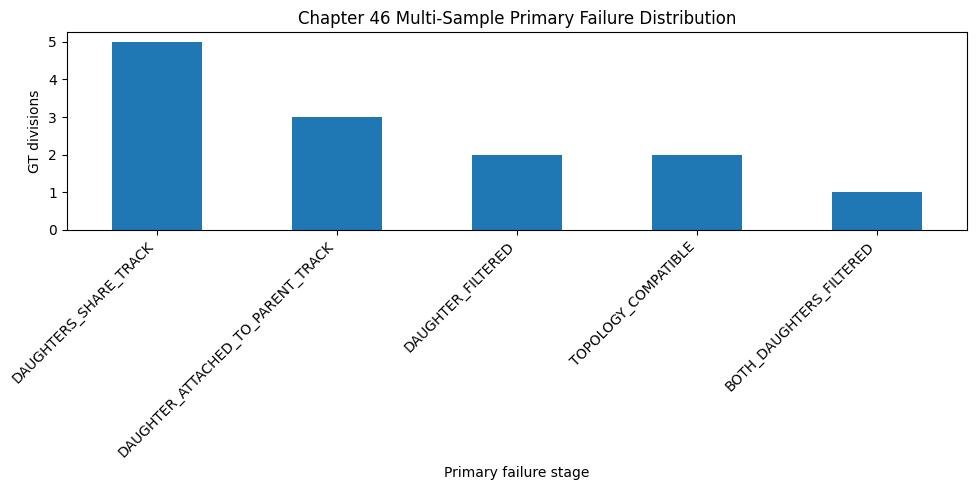

In [18]:
if len(failure_distribution):
    ax = failure_distribution.plot(
        x="failure_stage",
        y="count",
        kind="bar",
        legend=False,
        figsize=(10, 5),
    )
    ax.set_title("Chapter 46 Multi-Sample Primary Failure Distribution")
    ax.set_xlabel("Primary failure stage")
    ax.set_ylabel("GT divisions")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


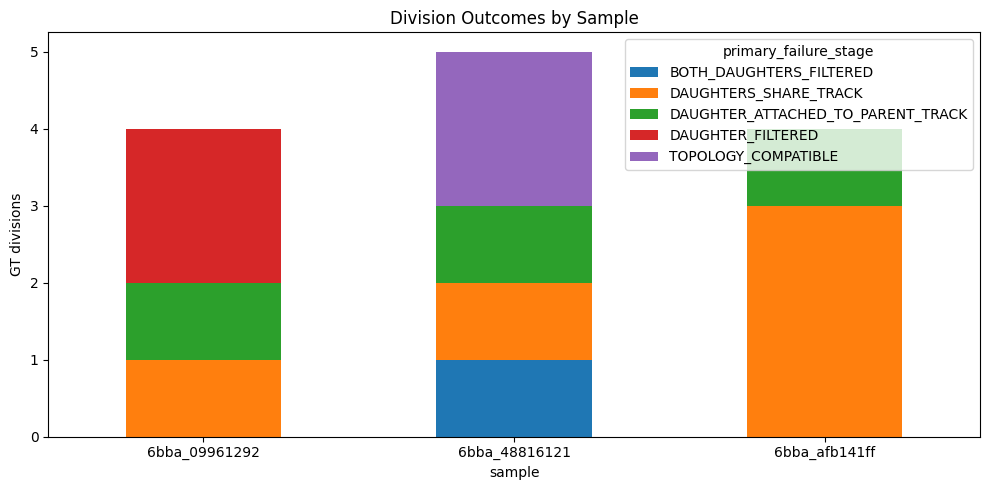

In [19]:
if len(audit_df):
    per_sample_plot = pd.crosstab(
        audit_df["sample_id"],
        audit_df["primary_failure_stage"],
    )
    ax = per_sample_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
    )
    ax.set_title("Division Outcomes by Sample")
    ax.set_ylabel("GT divisions")
    ax.set_xlabel("sample")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 9. Decision gate for Chapter 47

This cell does not prescribe a new algorithm. It converts the measured distribution into a research direction.

Interpretation:

- **Filtering dominates** → Chapter 47 should focus on division-preserving/context-aware filtering.
- **Topology dominates after daughters survive** → Chapter 47 should focus on division-aware track birth/splitting.
- **Candidate absence dominates** → return upstream to detection/ranking.
- **Mixed failures** → avoid a single narrow fix; inspect event-level patterns before redesign.


In [20]:
counts = audit_df["primary_failure_stage"].value_counts()

detection_failures = int(
    counts.get("NO_PARENT_CANDIDATE", 0)
    + counts.get("NO_DAUGHTER_A_CANDIDATE", 0)
    + counts.get("NO_DAUGHTER_B_CANDIDATE", 0)
)

filter_failures = int(
    counts.get("PARENT_FILTERED", 0)
    + counts.get("DAUGHTER_FILTERED", 0)
    + counts.get("BOTH_DAUGHTERS_FILTERED", 0)
)

topology_failures = int(
    counts.get("PARENT_TRACK_MISSING", 0)
    + counts.get("DAUGHTER_A_TRACK_MISSING", 0)
    + counts.get("DAUGHTER_B_TRACK_MISSING", 0)
    + counts.get("DAUGHTERS_SHARE_TRACK", 0)
    + counts.get("DAUGHTER_ATTACHED_TO_PARENT_TRACK", 0)
    + counts.get("DAUGHTER_TRACK_PREDATES_DIVISION", 0)
    + counts.get("TRACK_TOPOLOGY_INCOMPATIBLE", 0)
)

decision_table = pd.DataFrame([
    {"category": "detection/ranking", "count": detection_failures},
    {"category": "filtering", "count": filter_failures},
    {"category": "tracking/topology", "count": topology_failures},
    {
        "category": "topology compatible",
        "count": int(counts.get("TOPOLOGY_COMPATIBLE", 0)),
    },
])

decision_table["percent"] = 100 * decision_table["count"] / max(len(audit_df), 1)
display(decision_table)

failure_only = decision_table[
    decision_table["category"] != "topology compatible"
].sort_values("count", ascending=False)

if failure_only.empty or failure_only.iloc[0]["count"] == 0:
    recommendation = "No dominant measured failure category."
else:
    dominant = failure_only.iloc[0]["category"]
    if dominant == "filtering":
        recommendation = (
            "Filtering is the dominant measured failure category. "
            "Chapter 47 should test division-preserving/context-aware filtering."
        )
    elif dominant == "tracking/topology":
        recommendation = (
            "Tracking/topology is the dominant measured failure category. "
            "Chapter 47 should test division-aware track birth/splitting rather "
            "than another detection filter."
        )
    elif dominant == "detection/ranking":
        recommendation = (
            "Detection/ranking is the dominant measured failure category. "
            "Chapter 47 should return upstream before topology work."
        )
    else:
        recommendation = "Failure modes are mixed; inspect event-level results first."

print(recommendation)


,category,count,percent
0,detection/ranking,0,0.000000
1,filtering,3,23.076923
2,tracking/topology,8,61.538462
3,topology compatible,2,15.384615


Tracking/topology is the dominant measured failure category. Chapter 47 should test division-aware track birth/splitting rather than another detection filter.


## 10. Save audit artifacts

These outputs are the evidence base for the Chapter 47 design decision.


In [21]:
audit_path = CONFIG.output_dir / "chapter46_multisample_division_audit.csv"
failure_path = CONFIG.output_dir / "chapter46_failure_distribution.csv"
topology_path = CONFIG.output_dir / "chapter46_topology_summary.csv"
decision_path = CONFIG.output_dir / "chapter46_ch47_decision_table.csv"

audit_df.to_csv(audit_path, index=False)
failure_distribution.to_csv(failure_path, index=False)
topology_summary.to_csv(topology_path, index=False)
decision_table.to_csv(decision_path, index=False)

print("Saved:")
for p in [audit_path, failure_path, topology_path, decision_path]:
    print(" ", p)

print("\nChapter 46 V2 complete.")
print(
    f"Audited {len(audit_df)} binary GT divisions across "
    f"{audit_df['sample_id'].nunique()} samples."
)


Saved:
  /kaggle/working/chapter46_multisample_audit/chapter46_multisample_division_audit.csv
  /kaggle/working/chapter46_multisample_audit/chapter46_failure_distribution.csv
  /kaggle/working/chapter46_multisample_audit/chapter46_topology_summary.csv
  /kaggle/working/chapter46_multisample_audit/chapter46_ch47_decision_table.csv

Chapter 46 V2 complete.
Audited 13 binary GT divisions across 3 samples.
